# μBoone open data set anomaly detection

Note: The data needs to be downloaded seperately on your own. Open source data, python scripts, and jupyter notebooks derived from: https://github.com/uboone/OpenSamples/tree/main. Files downloaded should be put into the data folder. Furthermore this notebook will use only one file of the open wire data. Otherwise this project is way too heavy for what's intended to be a tutorial or supplement to the SCARAB project.

Before using this notebook follow the instructions listed in the OpenSamples repository, notably setting up the `ubopendata` conda environment with all the necessary libraries and packages. Furthermore, to best understand the autoencoder features for the microBooNe open data set, it's recommended to use the notebooks developed in the OpenSamples repository. 

The overall methodology of this will follow the unsupervised learning process developed by https://arxiv.org/pdf/2310.06047 and https://arxiv.org/abs/2509.21817v3. However, we will omit the student-teacher knowledge distillation methodology as we are constraining our training to a few files and with limited hardware, essentially only building the "teacher" autoencoder.

### Import libraries and useful data

Before this ensure you have set up the `ubopendata` conda environment which can be done by following the instructions from the OpenSamples repo. Put the wire data (one file or multiple) in the data folder and ideally in its own sub folder (example provided below).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

# Directly from uboone repo. Credits to Giuseppe Cerati for his code.
from microboone_utils import *
from pynuml.io import File


In [2]:
# walk up to the repo root, then into the data folder
repo_root = Path.cwd().parents[1]        # ../../ from tutorial/MBOONE
f = File(repo_root / "data" / "ubopendata" / "bnb_WithWire_00.h5")

# Print keys to see the structure of any useful data
print(f.keys())

<KeysViewHDF5 ['edep_table', 'event_table', 'hit_table', 'opflash_table', 'opflashsumpe_table', 'ophit_table', 'pandoraHit_table', 'pandoraPfp_table', 'pandoraPrimary_table', 'particle_table', 'wire_table']>


### Extracting useful data (wire)

Following the methodology from the RAD4HEP repository: https://github.com/NevisRAD/RAD4LArTPC/tree/main, we downsample to shrink the large data from all planes to only plane2. Any future modifications to the data will be made here in the notebook but otherwise process the data in `mod_data.py`. 

Make sure to conda activate `ubopendata` first and/or run `conda run --no-capture-output -n ubopendata python tutorial/MBOONE/mod_data.py` in the terminal. The reasons for these are due to errors presented when pressing the run button. This will process the bnb_WithWire file into a processed plane2 only file.

In [3]:
from mod_data_loader import WireImages

data = WireImages("../../data/ubopendata/processed_npy/bnb_WithWire_00_plane2_images.h5")
print(len(data), "events") # Sanity check


1085 events


### Getting key images from processed file 

Using the `mod_data_loader.py` script will allow us to use all the key information from the plane 2 wire data. Many images follow directly from `WireImage.ipynb` directly from: https://github.com/uboone/OpenSamples/tree/main, thus the goal for this is to sanity check that processing our file had no change to the data and is only for downscaling purposes. This will require using both unprocessed and processed files.

In [4]:
#Unprocessed original data (only a few events!). Reading 50 events of WithWire
# data at once is ~10 GB and triggers a MemoryError; we only need a couple of
# events to sanity-check the processed file against the raw file.
tables = ['event_table','wire_table','hit_table','edep_table']
for t in tables: f.add_group(t)
f.read_data(0, 20)
evts = f.build_evt()

### Plane 2 wire image with cuts (from the processed file)

This reproduces the **Plane 2** panel of `WireImage.ipynb`, but sourced from our compressed, plane-2-only processed file through `WireImages`. The loader applies the cutoff / saturation cuts on the fly (`cut=True`) and only reads the one event's chunk from disk. The time axis is downsampled by 10, so it spans 640 ticks instead of 6400.

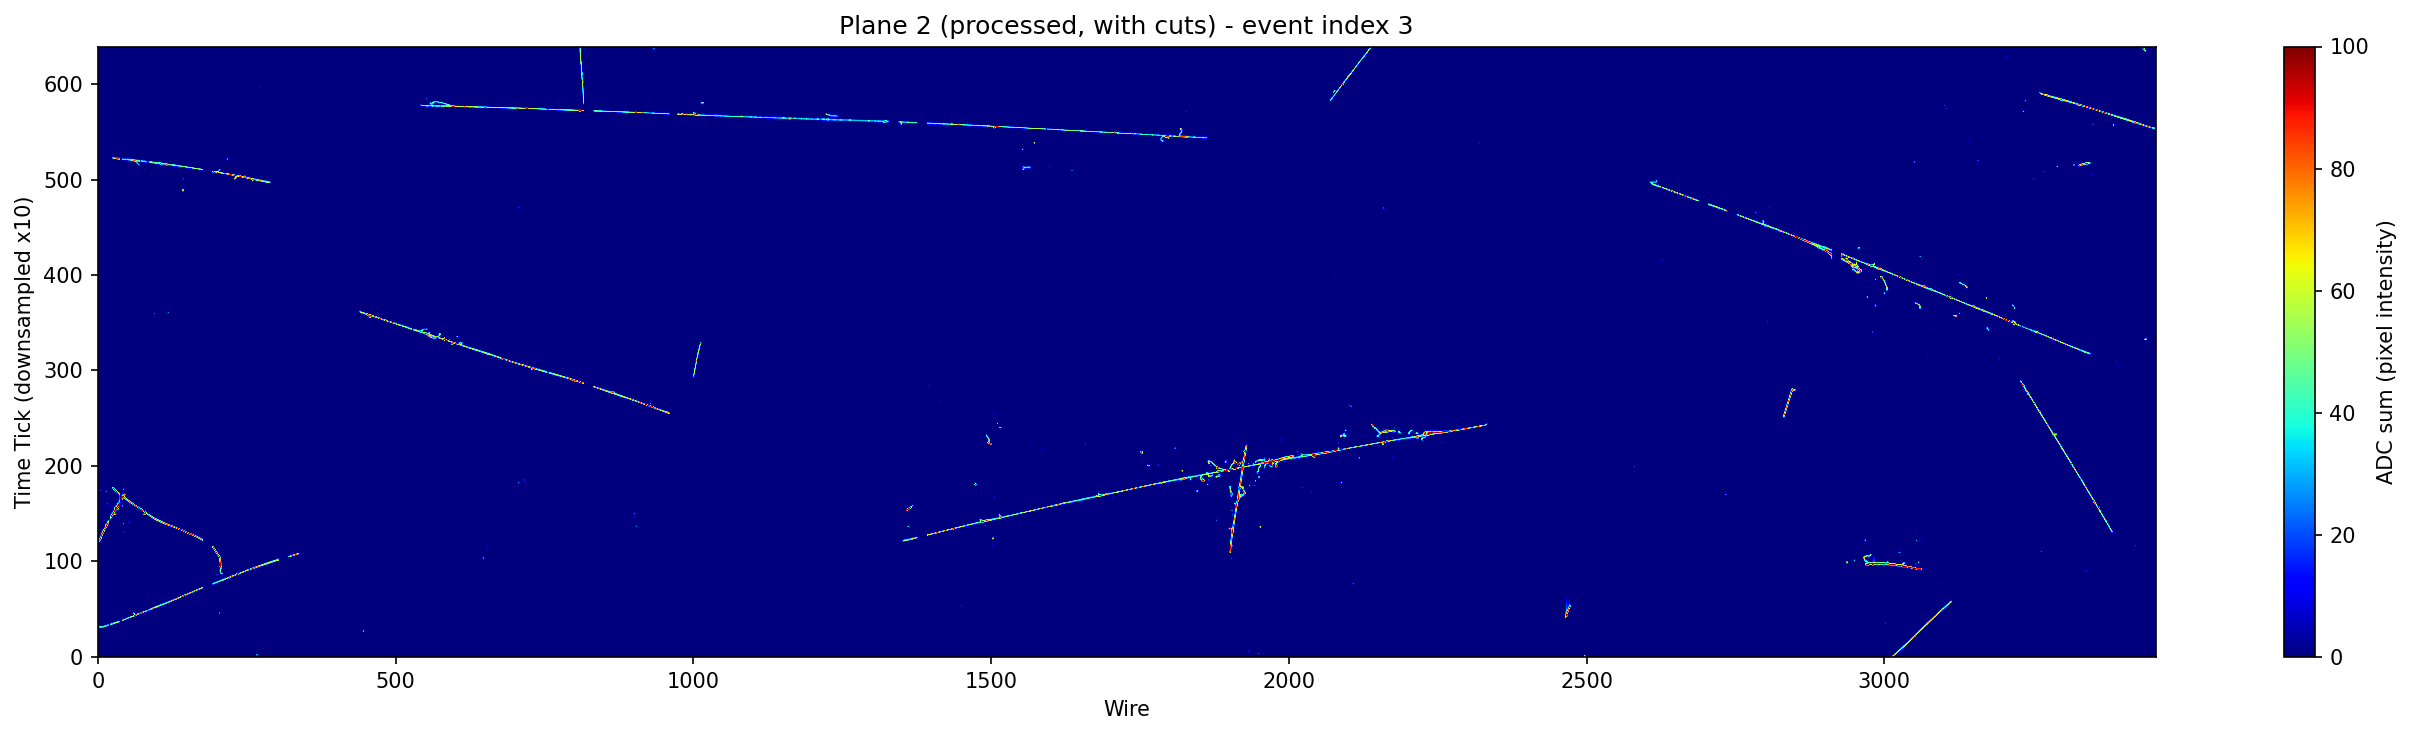

In [5]:
evt_index = 3   # which event to display (0 .. len(data)-1)

# Processed plane-2 image, cuts applied on the fly by the loader.
img_cut = data.full_image(evt_index, cut=True)   # shape (nwires=3456, time=640)
zmax = data.saturation                            # saturation value stored in the file (100)

plt.figure(figsize=(18, 5), dpi=150)
# transpose so Wire is on x and Time Tick on y, matching WireImage.ipynb
plt.imshow(img_cut.T, vmin=0, vmax=zmax, origin="lower", cmap="jet", aspect="auto")
plt.title("Plane 2 (processed, with cuts) - event index %d" % evt_index)
plt.xlabel("Wire")
plt.ylabel("Time Tick (downsampled x10)")
plt.colorbar(label="ADC sum (pixel intensity)")
plt.tight_layout()
plt.show()

### Sanity check: processed vs. unprocessed

To confirm the processing only downscaled the data (and didn't otherwise alter it), we recompute the same event's Plane 2 image **straight from the unprocessed file** (`evts`, loaded above) using the identical downsample factor (10) and cuts (10 / 100), then compare pixel-for-pixel.

The two agree to floating-point rounding (`max |diff|` ~ 1e-5, from the pandas `float64` path vs. the stored `float32`) — i.e. the processing changed nothing beyond the downsampling and cuts. With `evt_index = 1` this is event `(7004, 331, 16552)`, the same event shown in `WireImage.ipynb`.

event (run, subrun, event): [7004, 331, 16554]
shapes -> processed: (3456, 640)  raw recompute: (3456, 640)
max |processed - raw| = 1.52587890625e-05


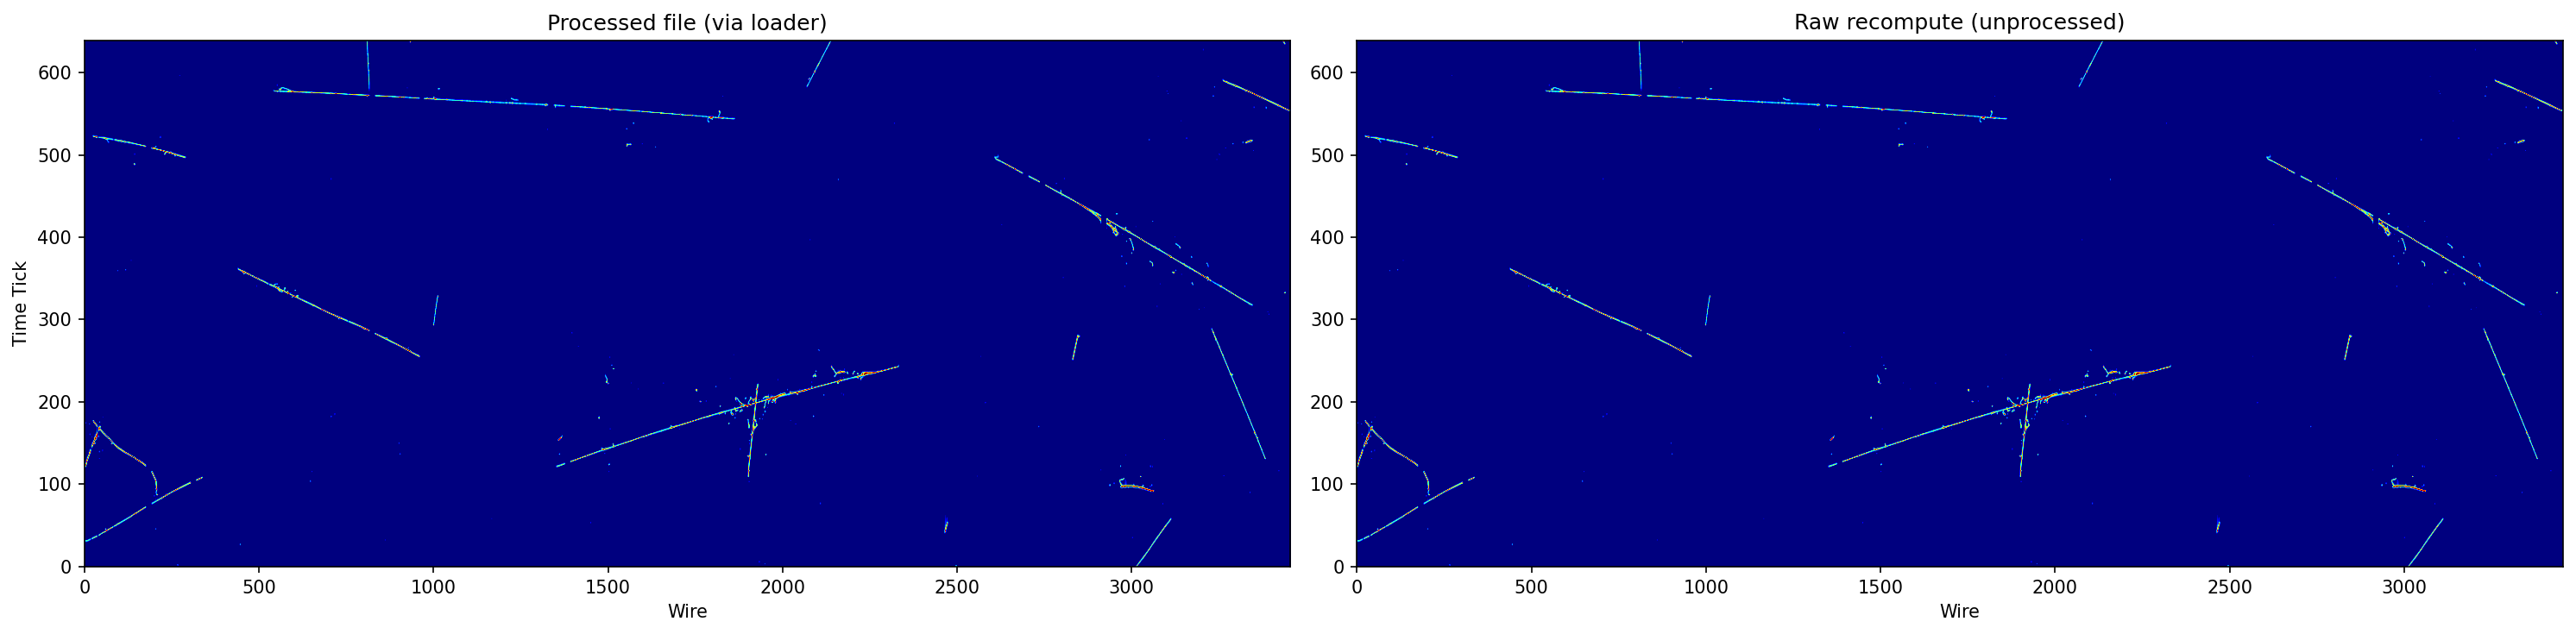

In [6]:
from skimage.measure import block_reduce

# Recompute plane 2 for the SAME event straight from the raw wire_table.
# (evt_index must be < the number of events read in the "Unprocessed original data" cell.)
evt = evts[evt_index]
evt_id = [evt["event_table"]["run"].iloc[0],
          evt["event_table"]["subrun"].iloc[0],
          evt["event_table"]["event"].iloc[0]]

raw_p2 = evt["wire_table"].query("local_plane==2")[
    ["adc_%i" % i for i in range(ntimeticks())]].to_numpy()
raw_ds = block_reduce(raw_p2, block_size=(1, 10), func=np.sum)   # downsample x10
raw_cut = raw_ds.copy()
raw_cut[raw_cut < data.cutoff] = 0
raw_cut[raw_cut > data.saturation] = data.saturation

print("event (run, subrun, event):", evt_id)
print("shapes -> processed:", img_cut.shape, " raw recompute:", raw_cut.shape)
print("max |processed - raw| =", float(np.max(np.abs(img_cut - raw_cut))))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(20, 5), dpi=150)
axL.imshow(img_cut.T, vmin=0, vmax=zmax, origin="lower", cmap="jet", aspect="auto")
axL.set_title("Processed file (via loader)"); axL.set_xlabel("Wire"); axL.set_ylabel("Time Tick")
axR.imshow(raw_cut.T, vmin=0, vmax=zmax, origin="lower", cmap="jet", aspect="auto")
axR.set_title("Raw recompute (unprocessed)"); axR.set_xlabel("Wire")
plt.tight_layout()
plt.show()

### The segment "slices" (visualizing the image input segments)

The grids above show *where* the slices fall; the loader also returns the **actual tiles** via `data.segments(evt_index, seg_wire, seg_time)` — shape `(n_tiles, seg_wire, seg_time, 1)`, with the cuts already applied. Tiling is lossless: the tiles reassemble exactly into the cut full image.

Two ways to look at them below:
1. **Montage** of the individual tiles — practical for `864×64` (40 tiles/event). `64×32` and `18×16` produce 1080 and 7680 tiles/event, too many to montage, so use the grid overlay for those.
2. **Grid overlay** — draws the segment boundaries on the full image; scales to any size.

To get the tiles for a *different* size, just change `seg_wire, seg_time` — no reprocessing (this is why we store the full image once). And for training you would stream them with `data.batches(seg_wire, seg_time, batch_size=...)` rather than materialize them.

segments: (40, 864, 64, 1) -> 4 x 10 = 40 tiles


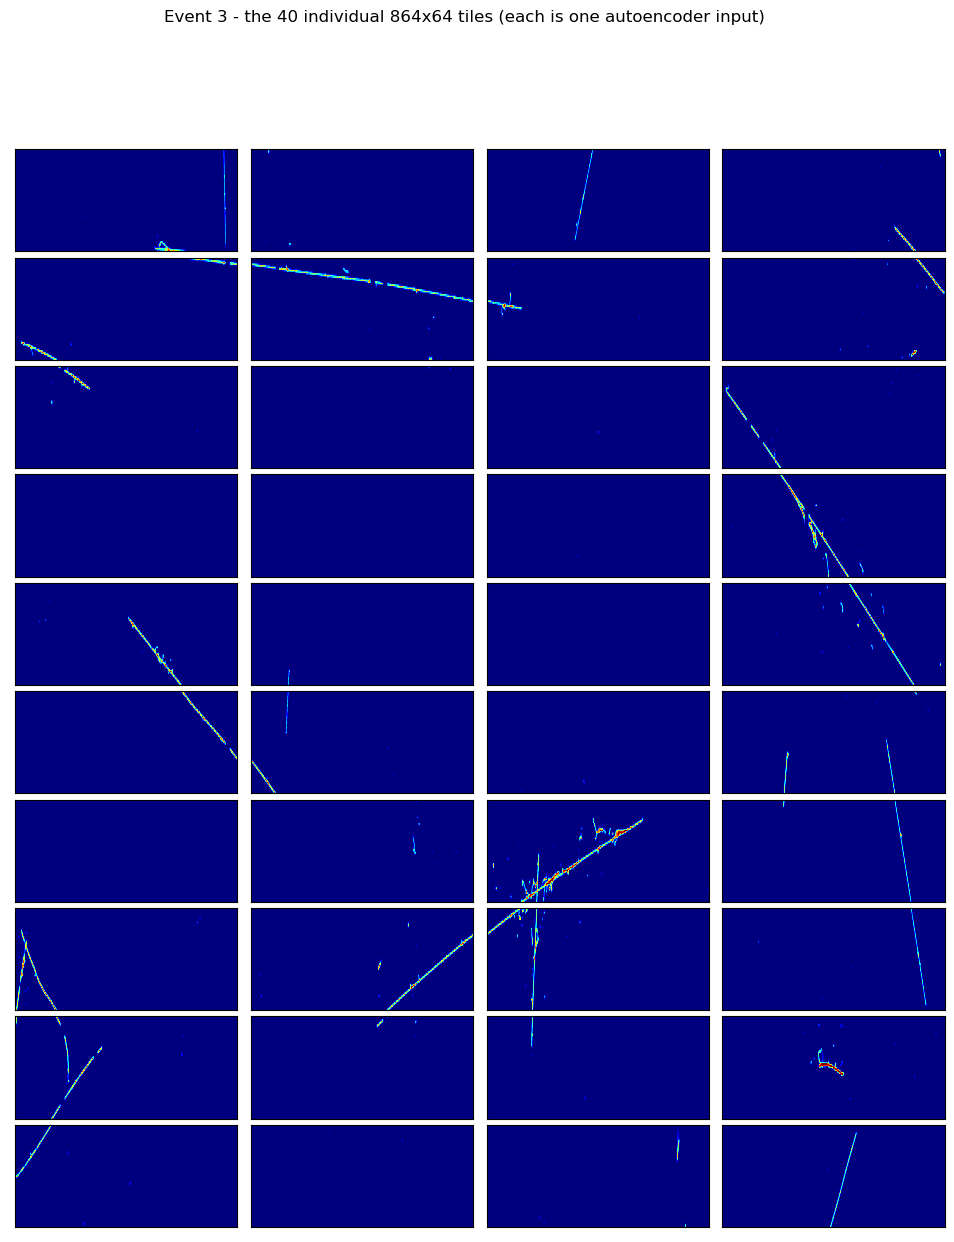

In [7]:
seg_wire, seg_time = 864, 64
segs = data.segments(evt_index, seg_wire, seg_time)          # (n_tiles, seg_wire, seg_time, 1), cuts applied
v_split = data.ds.shape[1] // seg_wire                        # wire blocks (x)
h_split = data.ds.shape[2] // seg_time                        # time blocks (y)
print("segments:", segs.shape, "->", v_split, "x", h_split, "=", segs.shape[0], "tiles")

# montage the tiles in their spatial layout (they reassemble into the full image)
fig, axes = plt.subplots(h_split, v_split, figsize=(12, 14),
                         gridspec_kw=dict(wspace=0.06, hspace=0.06))
for k in range(segs.shape[0]):
    vv, hh = k // h_split, k % h_split                       # wire-block, time-block
    ax = axes[h_split - 1 - hh, vv]                          # low time at the bottom
    ax.imshow(segs[k, :, :, 0].T, vmin=0, vmax=data.saturation,
              origin="lower", cmap="jet", aspect="auto")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Event %d - the %d individual %dx%d tiles (each is one autoencoder input)"
             % (evt_index, segs.shape[0], seg_wire, seg_time))
plt.show()

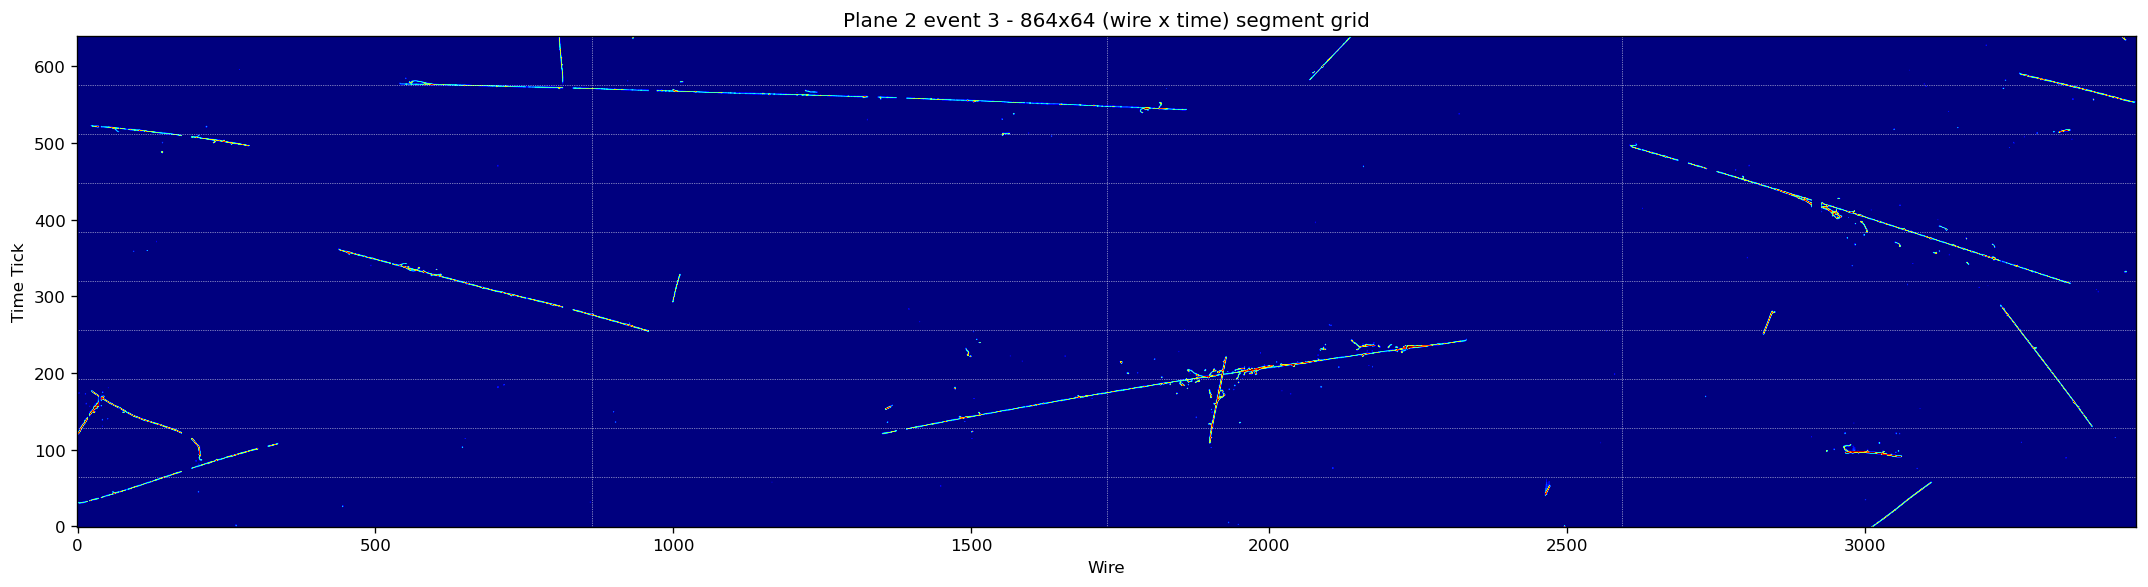

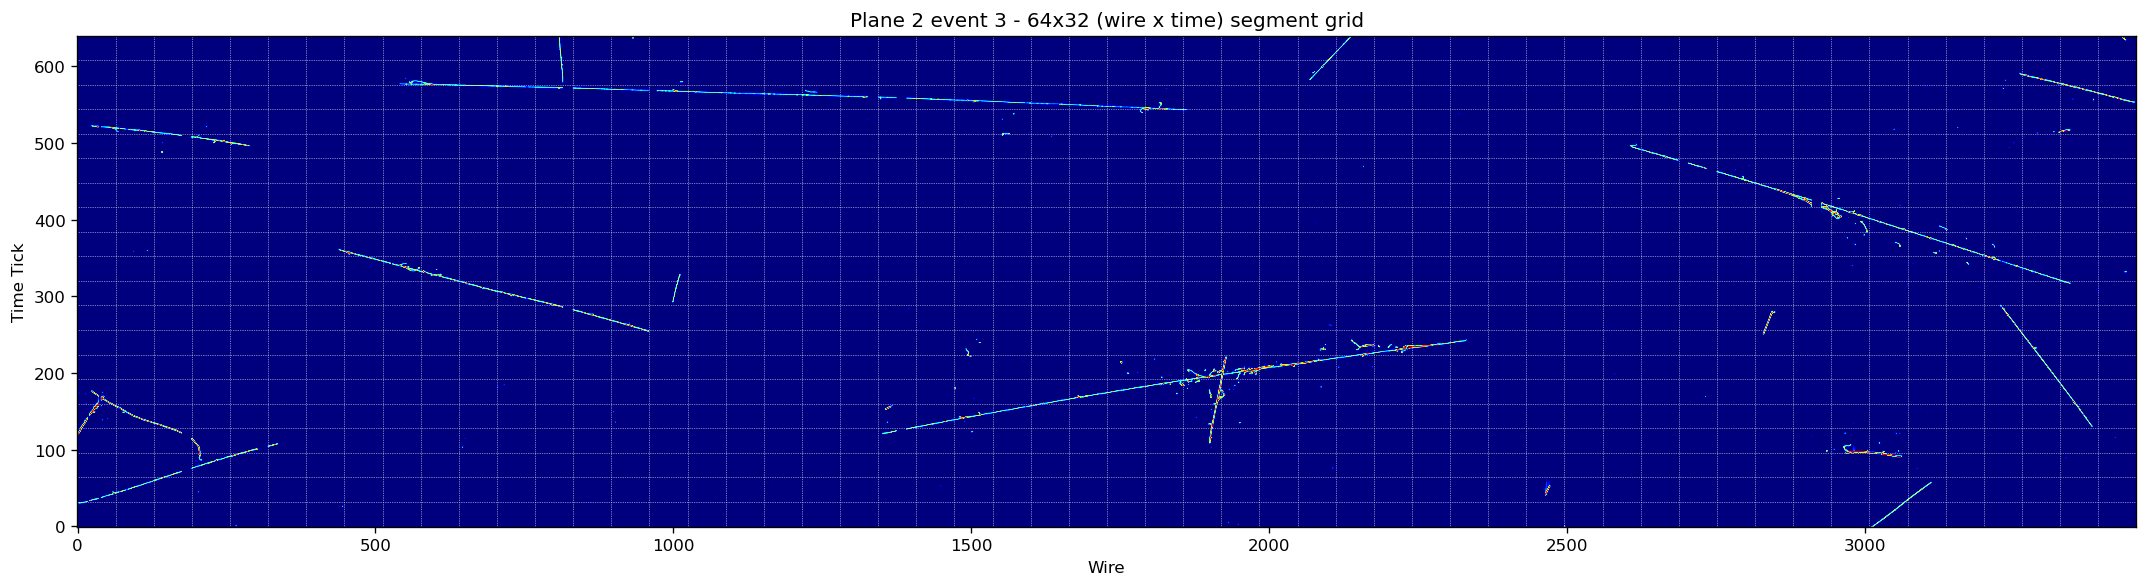

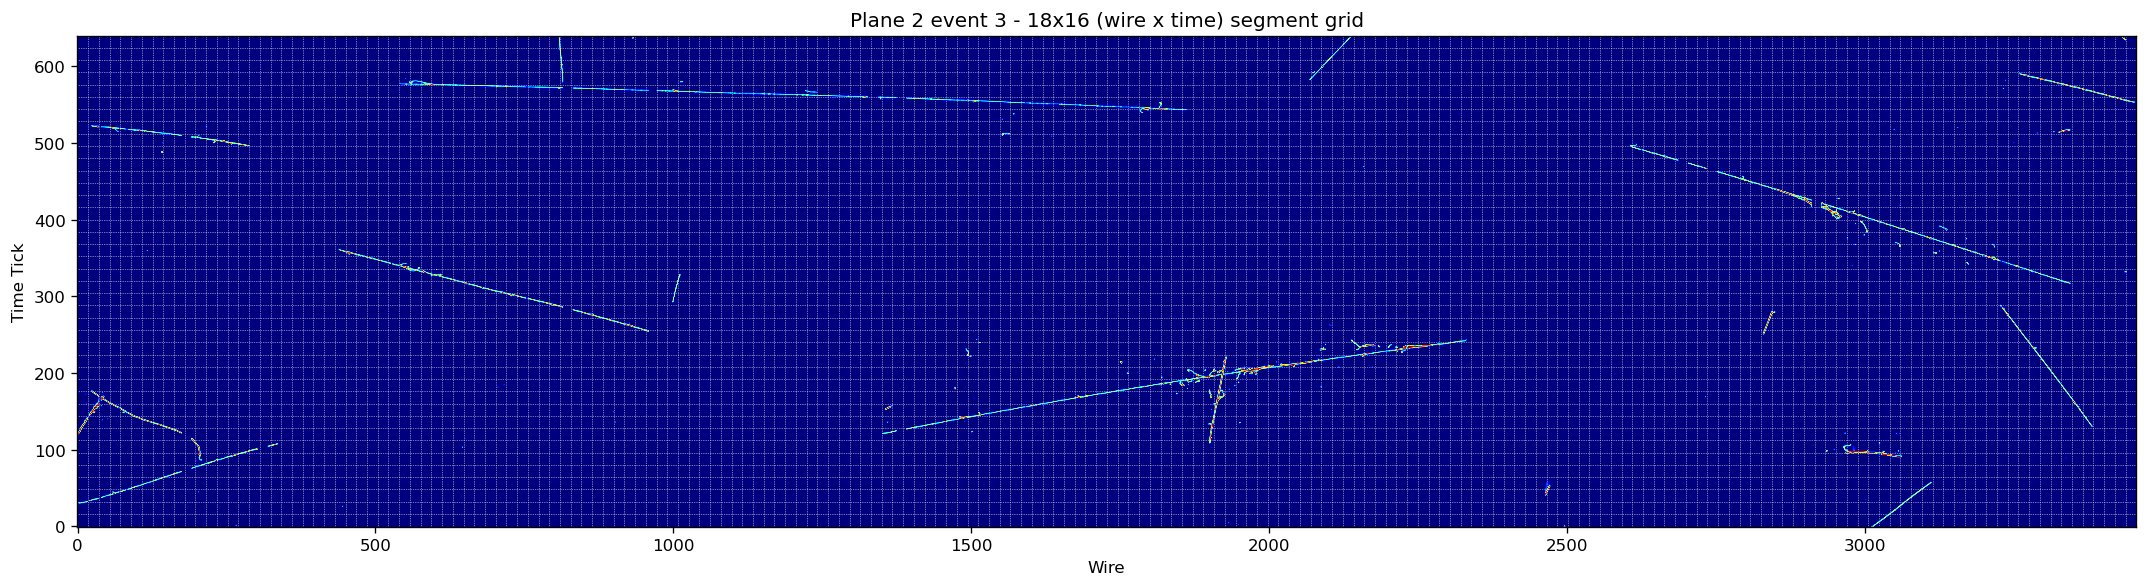

In [8]:
# Boundary overlay: full image with the segment grid drawn on top.
# This scales to ALL sizes (montaging 64x32 / 18x16 is impractical: 1080 / 7680 tiles).
def plot_segment_grid(evt_index, seg_wire, seg_time):
    img = data.full_image(evt_index, cut=True)               # (wire, time), cuts applied
    W, T = img.shape
    plt.figure(figsize=(18, 5), dpi=120)
    plt.imshow(img.T, vmin=0, vmax=data.saturation, origin="lower", cmap="jet", aspect="auto")
    for x in range(seg_wire, W, seg_wire): plt.axvline(x, color="w", lw=0.4, ls=":")
    for y in range(seg_time, T, seg_time): plt.axhline(y, color="w", lw=0.4, ls=":")
    plt.title("Plane 2 event %d - %dx%d (wire x time) segment grid" % (evt_index, seg_wire, seg_time))
    plt.xlabel("Wire"); plt.ylabel("Time Tick"); plt.tight_layout(); plt.show()

for sw, st in [(864, 64), (64, 32), (18, 16)]:
    plot_segment_grid(evt_index, sw, st)

### Training Autoencoder

When running please only use the `base` env NOT `ubopendata` nor `scarab`. The reason for this is due to TensorFlow version differences. Furthermore the process here will differ greatly from the processes above, as the actual input data for the autoencoder will be found in `\inputData`.



Note "teacher" here follows the definition of the "teacher autoencoder" as defined by: https://arxiv.org/abs/2509.21817v3. We are not using knowledge distillation in order to actually train our autoencoder.


Then once you check everything is clean, run:

`conda run --no-capture-output -n base python tutorial/MBOONE/training.py --input "inputData/....18x16.npy" --epochs 20` 



To actually do the training, follow the exact process in the new `base` environment if in the `/tutorial/MBOONE/` directory (not `ubopendata` and not `scarab` because of the TensorFlow conflicts):

1.) Export the three cut files into a `.npy` file via the command: `conda run --no-capture-output -n base python mod_data_loader.py --h5 "../../data/ubopendata/processed_npy/bnb_WithWire_00_plane2_images.h5" --out-dir inputData --events 128` 


2.) Self test the module (follows from the original self test stated above): `conda run --no-capture-output -n base python training.py --self-test` as a sanity check


3.) Then run the command to train the encoder: `conda run --no-capture-output -n base python training.py --input "inputData/bnb_WithWire_00_plane2_18x16.npy" --epochs 20`. Note that 18x16 is the current set default. Edit the input file name and the actual dimensions in the `training.py` code.



If in the base path, follow:

1.) Export the three cut files via: `conda run --no-capture-output -n base python tutorial/MBOONE/mod_data_loader.py --h5 data/ubopendata/processed_npy/bnb_WithWire_00_plane2_images.h5 --out-dir inputData --events 128`. Where the events caps how many events will be trained. Do keep in mind that there will likely be overfitting for the 864x64 wire images with a low quantity of evnts.

2.) Do a sanity self test: `conda run --no-capture-output -n base python tutorial/MBOONE/training.py --self-test`

3.) Finally run the train command but keep in mind the naming of the specific file prior to running: `conda run --no-capture-output -n base python tutorial/MBOONE/training.py --input inputData/bnb_WithWire_00_plane2_864x64.npy --epochs 20`


### Important Note:

Training on 864x64 wirextime data can be very intense on the memory. I expect training on all 1085 events to be very taxing on memory and thus yield OOM errors. As such I do recommend training on batches (~16 for instance). The command would look as such:

`conda run --no-capture-output -n base python tutorial/MBOONE/training.py --input inputData/bnb_WithWire_00_plane2_864x64.npy --epochs 20 --batch-size 16`


### Plotting Loss and Anomaly Score

A key preface is that the 18x16 images will be trained on 128 events however for the 64x32 images and the 864x64 images we will be trained on all events. The key motivation is that we want to train on a roughly equal number of samples. However for the 864x64 images we can only get so many training segments for one file. The idea is to ensure proper training and such that the 864x64 images are trained properly without overfitting. 

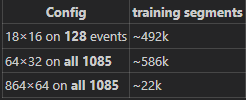

18x16: n=20000  median=0  p99=14.05  max=323.9  (95% of sample empty)
64x32: n=20000  median=0  p99=34.12  max=513.6  (84% of sample empty)
864x64: n=4000  median=5.137  p99=75.01  max=469.6  (10% of sample empty)


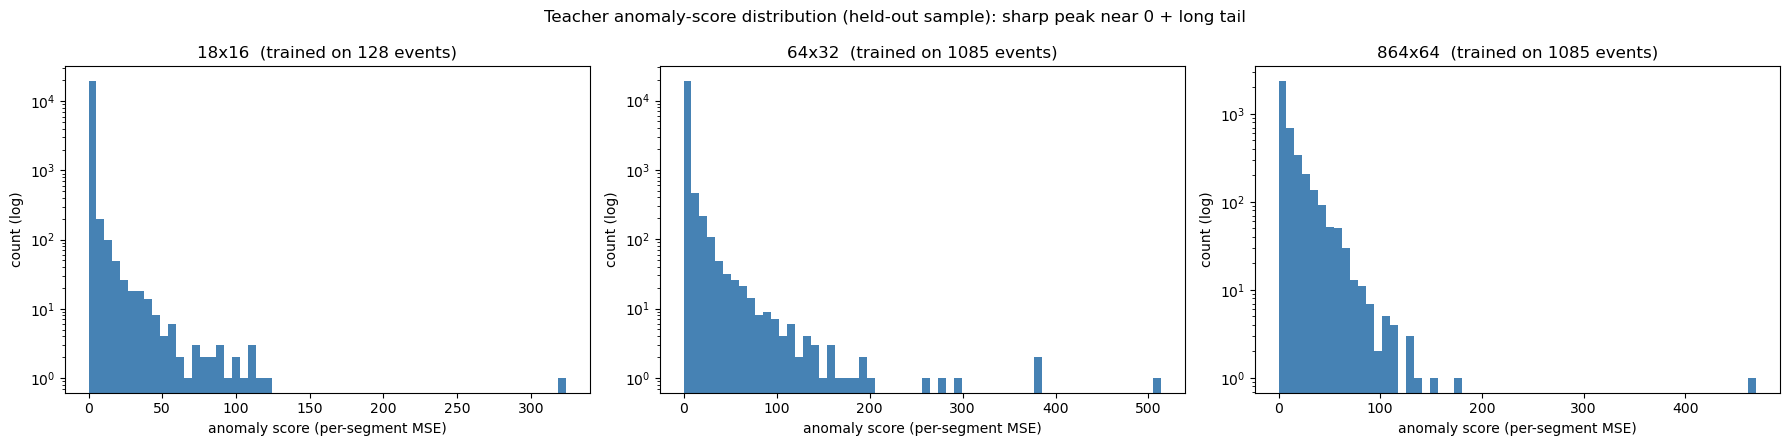

In [11]:
# PHASE 1 - Load the trained teachers and check the anomaly-score distribution.
# Run this in the `base` env (needs TensorFlow). Self-contained: imports + paths below.
# All three cuts: 18x16 (128 events), 64x32 and 864x64 (all 1085 events).
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from training import anomaly_score, total_pixel_intensity   # our own definitions

rng = np.random.default_rng(0)

def find_model(base):                # prefer the .h5 save format, fall back to .keras
    for ext in (".h5", ".keras"):
        if os.path.exists(base + ext):
            return base + ext
    raise FileNotFoundError(base + ".{h5,keras} not found")

# (label, model file WITHOUT extension, .npy file, TRAINING events, sample size, predict batch)
# 864x64 segments are ~221 KB each, so use a smaller sample + small predict batch to stay in RAM.
CONFIGS = [
    ("18x16",  "../../savedModel/teacher_18x16",  "../../inputData/bnb_WithWire_00_plane2_18x16.npy",  128,  20000, 1024),
    ("64x32",  "../../savedModel/teacher_64x32",  "../../inputData/bnb_WithWire_00_plane2_64x32.npy",  1085, 20000, 512),
    ("864x64", "../../savedModel/teacher_864x64", "../../inputData/bnb_WithWire_00_plane2_864x64.npy", 1085, 4000,  16),
]

eval_data = {}   # reused by the reconstruction cells further down
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(18, 4.5))
for ax, (label, mbase, npath, nev, nsamp, pbatch) in zip(axes, CONFIGS):
    model = keras.models.load_model(find_model(mbase), compile=False)
    mm = np.load(npath, mmap_mode="r")                       # 9.6 GB file, memory-mapped
    idx = np.sort(rng.choice(mm.shape[0], size=min(nsamp, mm.shape[0]), replace=False))
    X = np.asarray(mm[idx], dtype="float32")                 # load only the sampled rows
    scores = anomaly_score(model, X, batch_size=pbatch)
    eval_data[label] = dict(model=model, X=X, scores=scores, nev=nev, pbatch=pbatch)

    ax.hist(scores, bins=60, log=True, color="steelblue")
    ax.set_title("%s  (trained on %d events)" % (label, nev))
    ax.set_xlabel("anomaly score (per-segment MSE)"); ax.set_ylabel("count (log)")
    print("%s: n=%d  median=%.4g  p99=%.4g  max=%.4g  (%.0f%% of sample empty)"
          % (label, len(X), np.median(scores), np.percentile(scores, 99), scores.max(),
             100 * np.mean(total_pixel_intensity(X) == 0)))
fig.suptitle("Teacher anomaly-score distribution (held-out sample): sharp peak near 0 + long tail")
plt.tight_layout(); plt.show()

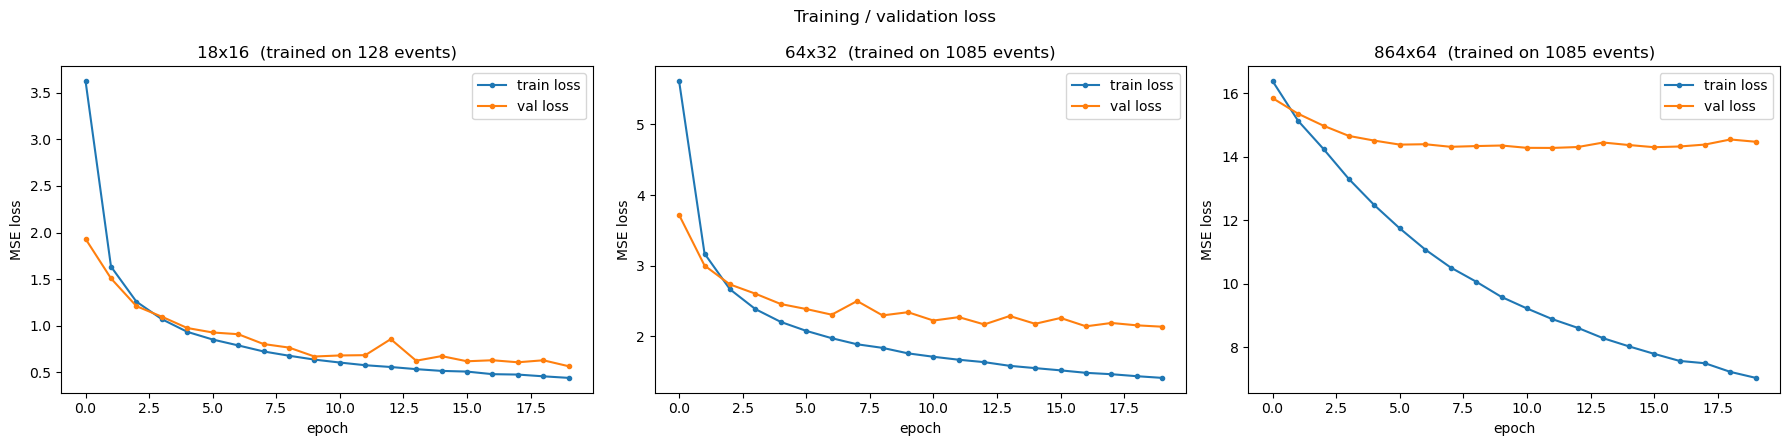

In [3]:
# PHASE 1 - Training / validation loss curves from the saved history CSVs (all three cuts).
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (label, nev) in zip(axes, [("18x16", 128), ("64x32", 1085), ("864x64", 1085)]):
    h = np.genfromtxt("../../savedModel/teacher_%s_history.csv" % label, delimiter=",", names=True)
    ax.plot(h["epoch"], h["loss"], "-o", ms=3, label="train loss")
    ax.plot(h["epoch"], h["val_loss"], "-o", ms=3, label="val loss")
    ax.set_title("%s  (trained on %d events)" % (label, nev))
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss"); ax.legend()
fig.suptitle("Training / validation loss")
plt.tight_layout(); plt.show()

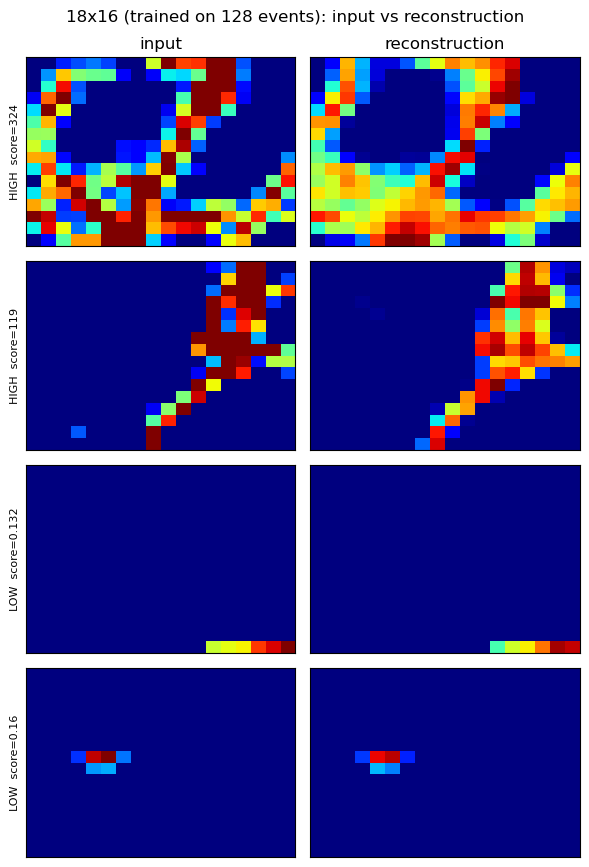

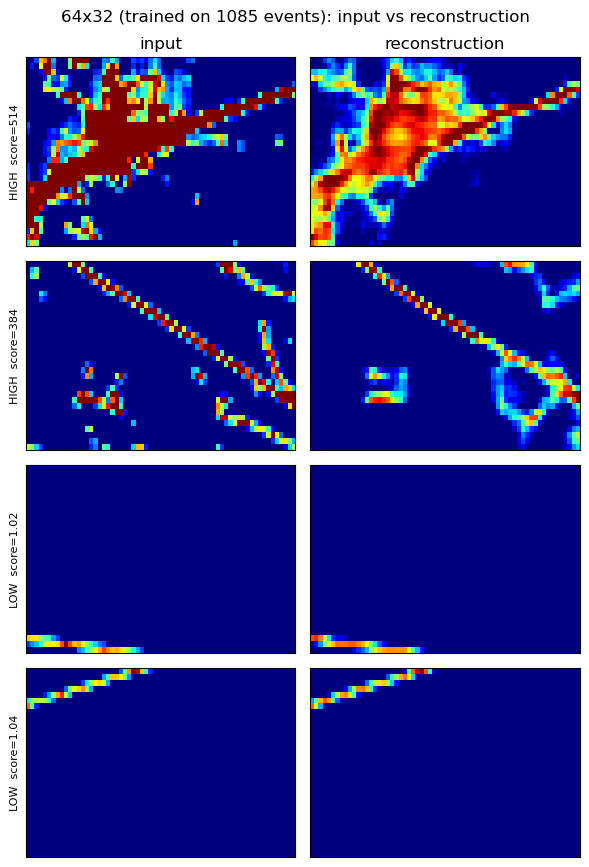

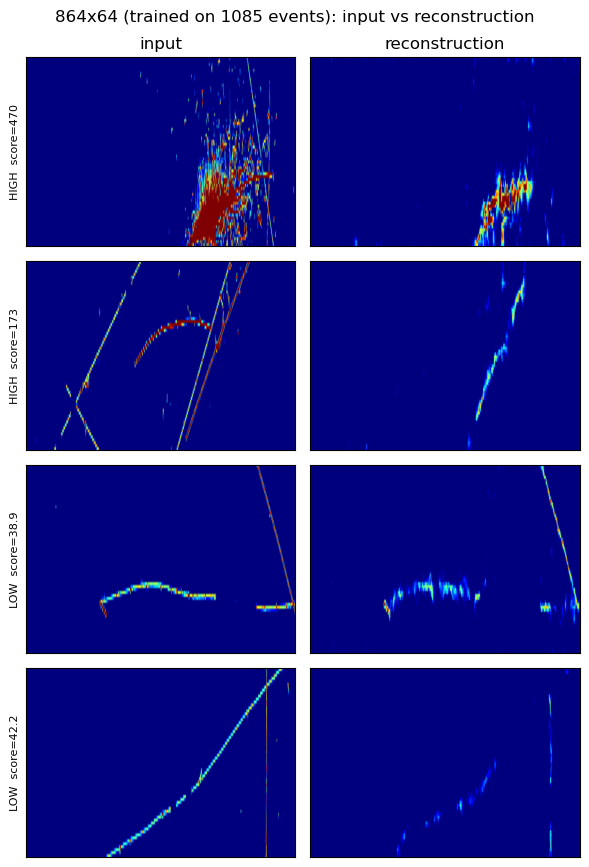

In [4]:
# PHASE 2 - High vs low anomaly-score segments: input next to the model's reconstruction.
# All three cuts. Reuses the models + scored samples from the anomaly-score cell above (run that first).
import numpy as np
import matplotlib.pyplot as plt

for label in ["18x16", "64x32", "864x64"]:
    d = eval_data[label]
    model, X, scores = d["model"], d["X"], d["scores"]

    frac = (X > 0).reshape(len(X), -1).mean(axis=1)     # fraction of lit pixels per segment
    order = np.argsort(scores)                            # ascending score
    pool = order[frac[order] >= 0.02]                     # only segments with a real track
    picks = list(pool[-2:][::-1]) + list(pool[:2])        # 2 highest score, then 2 lowest
    tags = ["HIGH", "HIGH", "LOW", "LOW"]
    recon = model.predict(X[picks], verbose=0, batch_size=d["pbatch"])

    fig, axes = plt.subplots(len(picks), 2, figsize=(6, 2.2 * len(picks)))
    for r, (k, tag) in enumerate(zip(picks, tags)):
        vmax = max(1.0, float(X[k].max()))
        axes[r, 0].imshow(X[k, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
        axes[r, 0].set_ylabel("%s  score=%.3g" % (tag, scores[k]), fontsize=8)
        axes[r, 1].imshow(recon[r, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
        for c in (0, 1):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[0, 0].set_title("input"); axes[0, 1].set_title("reconstruction")
    fig.suptitle("%s (trained on %d events): input vs reconstruction" % (label, d["nev"]))
    plt.tight_layout(); plt.show()

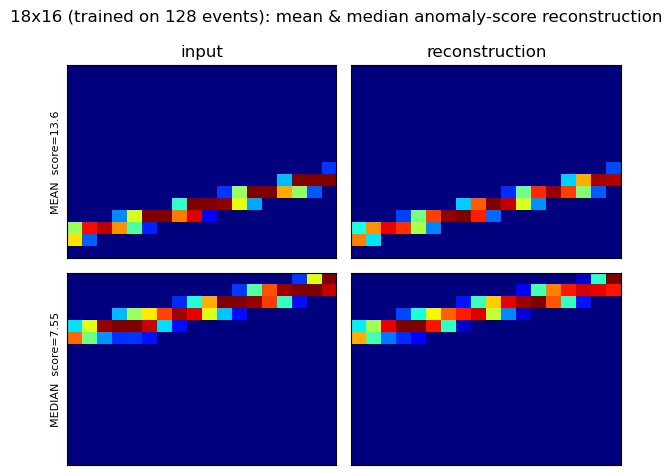

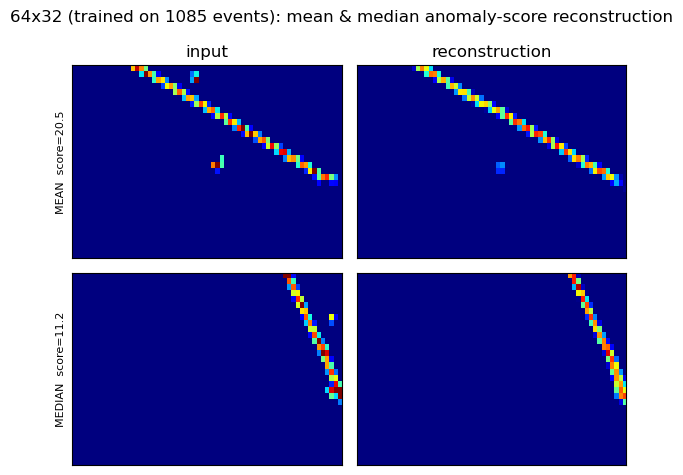

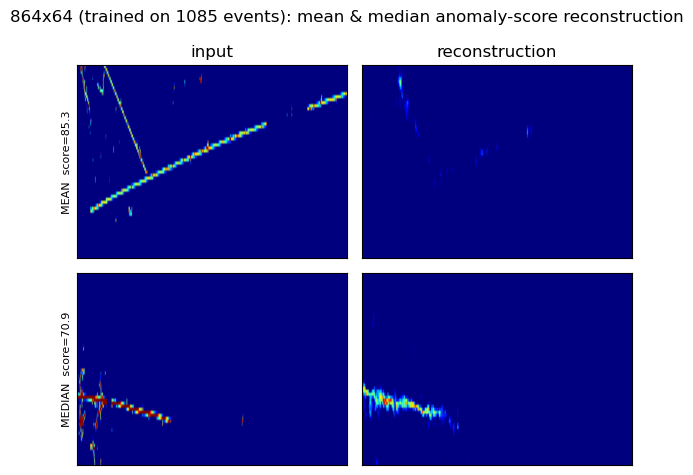

In [5]:
# PHASE 2 (cont.) - MEAN and MEDIAN anomaly-score segments: input vs reconstruction (all three cuts).
# Representatives are taken among segments with a real track (frac >= 0.02), matching the
# high/low cell -- otherwise the median would just be an empty tile (the raw median score
# is 0, since most segments are empty). Reuses eval_data from the anomaly-score cell above.
import numpy as np
import matplotlib.pyplot as plt

for label in ["18x16", "64x32", "864x64"]:
    d = eval_data[label]
    model, X, scores = d["model"], d["X"], d["scores"]

    frac = (X > 0).reshape(len(X), -1).mean(axis=1)       # fraction of lit pixels per segment
    pool = np.where(frac >= 0.02)[0]                       # segments with a real track
    s = scores[pool]
    picks = [pool[np.argmin(np.abs(s - s.mean()))],       # closest to the MEAN score
             pool[np.argmin(np.abs(s - np.median(s)))]]   # closest to the MEDIAN score
    tags = ["MEAN", "MEDIAN"]
    recon = model.predict(X[picks], verbose=0, batch_size=d["pbatch"])

    fig, axes = plt.subplots(len(picks), 2, figsize=(6, 2.4 * len(picks)))
    for r, (k, tag) in enumerate(zip(picks, tags)):
        vmax = max(1.0, float(X[k].max()))
        axes[r, 0].imshow(X[k, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
        axes[r, 0].set_ylabel("%s  score=%.3g" % (tag, scores[k]), fontsize=8)
        axes[r, 1].imshow(recon[r, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
        for c in (0, 1):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[0, 0].set_title("input"); axes[0, 1].set_title("reconstruction")
    fig.suptitle("%s (trained on %d events): mean & median anomaly-score reconstruction"
                 % (label, d["nev"]))
    plt.tight_layout(); plt.show()

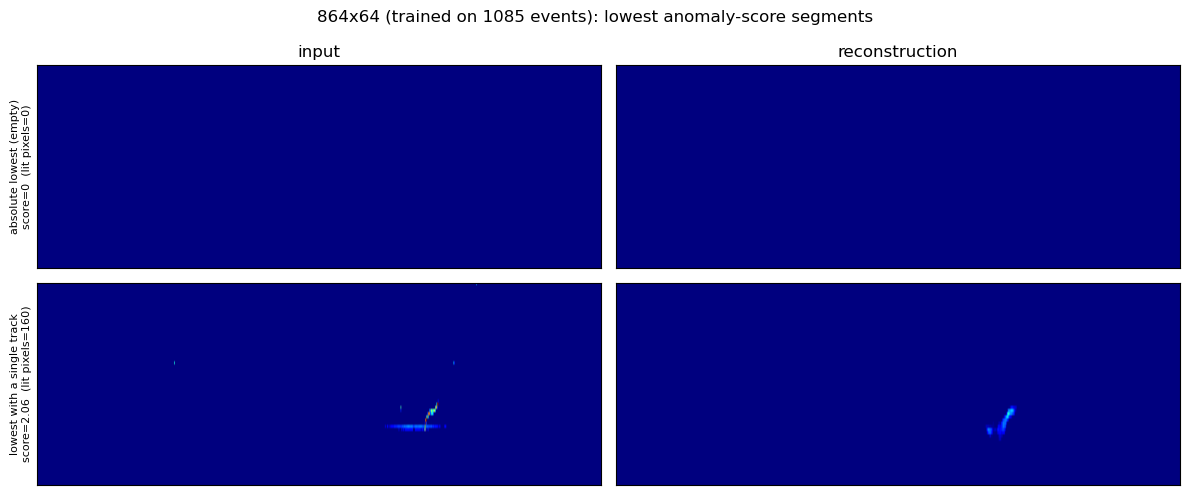

In [6]:
# PHASE 2 (cont.) - 864x64: the lowest anomaly-score segments, input vs reconstruction.
# The absolute lowest score is an empty tile (trivially reconstructed); the lowest score
# *with a real track* shows how well the model reconstructs the simplest genuine content --
# a clean single track. Selection uses an absolute lit-pixel floor (>=150), since a fraction
# threshold scales badly with the big 864x64 tile area. Reuses eval_data from above.
import numpy as np
import matplotlib.pyplot as plt

d = eval_data["864x64"]
model, X, scores = d["model"], d["X"], d["scores"]

lit = (X > 0).reshape(len(X), -1).sum(axis=1)          # lit-pixel count per segment
k_empty = int(np.argmin(scores))                        # absolute lowest (an empty tile)
track = np.where(lit >= 150)[0]                         # segments containing a real track
k_track = int(track[np.argmin(scores[track])])          # lowest score among those (a single track)

picks = [k_empty, k_track]
tags = ["absolute lowest (empty)", "lowest with a single track"]
recon = model.predict(X[picks], verbose=0, batch_size=d["pbatch"])

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
for r, (k, tag) in enumerate(zip(picks, tags)):
    vmax = max(1.0, float(X[k].max()))
    axes[r, 0].imshow(X[k, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
    axes[r, 0].set_ylabel("%s\nscore=%.3g  (lit pixels=%d)" % (tag, scores[k], int(lit[k])), fontsize=8)
    axes[r, 1].imshow(recon[r, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
    for c in (0, 1):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_title("input"); axes[0, 1].set_title("reconstruction")
fig.suptitle("864x64 (trained on %d events): lowest anomaly-score segments" % d["nev"])
plt.tight_layout(); plt.show()

### Pixel intensity correlation with anomaly score

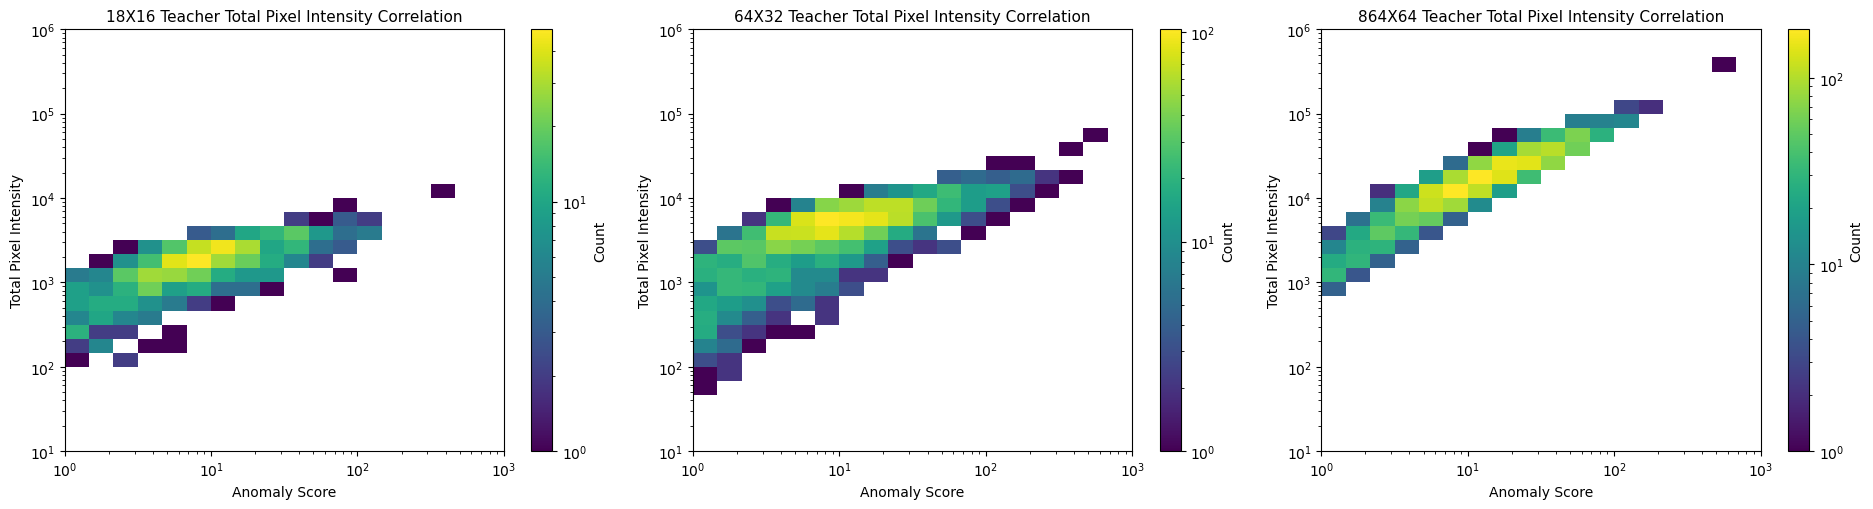

In [8]:
# Paper Figure 12, for all three cuts: Teacher anomaly score vs total pixel intensity.
# A positive trend means segments with more ionization (higher total intensity) have larger
# possible reconstruction loss -> harder to reconstruct -> higher anomaly score. This trivial
# correlation is what the *scaled* anomaly score divides out. Paper excludes scores below 1.
# Reuses eval_data from the anomaly-score cell above (run that first, in the `base` env).
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from training import total_pixel_intensity

xbins = np.logspace(0, 3, 19)     # anomaly score          1 .. 1e3  (~6 bins/decade)
ybins = np.logspace(1, 6, 31)     # total pixel intensity  10 .. 1e6

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
for ax, label in zip(axes, ["18x16", "64x32", "864x64"]):
    d = eval_data[label]
    s, ti = d["scores"], total_pixel_intensity(d["X"])
    m = (s >= 1) & (ti > 0)                              # paper: exclude anomaly scores below 1
    h = ax.hist2d(s[m], ti[m], bins=[xbins, ybins], norm=LogNorm(), cmap="viridis")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(1, 1e3); ax.set_ylim(1e1, 1e6)
    ax.set_title("%s Teacher Total Pixel Intensity Correlation" % label.upper(), fontsize=11)
    ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Total Pixel Intensity")
    fig.colorbar(h[3], ax=ax, label="Count")
plt.tight_layout(); plt.show()

### ROC-AUC vs track multiplicity (≥1, ≥2, ≥3 tracks)

A single track is "normal", so the ≥1 fair test above is only modestly discriminating. Anomaly detection is meant to flag **busy, multi-track** activity, so we sweep the signal definition — a tile is *signal* if it holds **≥ N distinct Geant4 tracks** (each with ≥ 5 plane-2 hits), against the same cosmic-activity background. This mirrors the FIREFLY paper (Fig. 16), whose headline AUC (~0.93) is for **≥ 3 tracks**, not ≥ 1.

Here there is **one panel per grid slice** (18×16, 64×32, 864×64), and within each panel the three curves are the ≥1, ≥2, ≥3 track requirements — so each panel directly shows the AUC **climbing as multiplicity rises**.

Multi-track tiles are genuinely rare (over all 1085 events there are only ~230–400 tiles with ≥ 3 tracks per cut), so to keep decent statistics we evaluate **400 events** but score only the signal tiles plus a random per-event sample of background tiles (an unbiased ROC that runs in ~3 min). The signal count `n_sig` is printed on every curve — the ≥3 curve is the lowest-statistics case, so read it with that caveat.

c:\Users\aidan\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


18x16 done
64x32 done
864x64 done


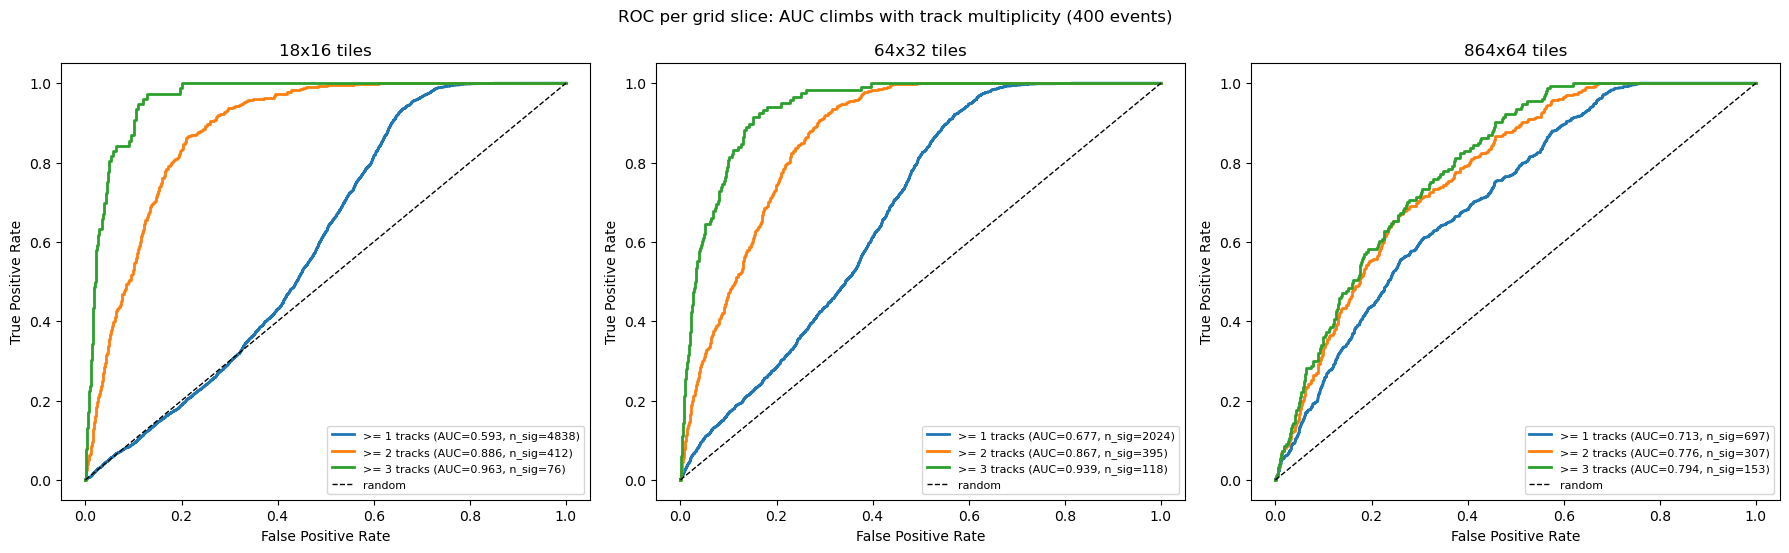

In [1]:
# ROC-AUC per GRID SLICE, curves = track MULTIPLICITY (>=1, >=2, >=3): fair test = N-track signal vs
# cosmic background. Same "track" definition and searchsorted event->edep mapping as the cell above.
# To afford 400 events we score only the SIGNAL tiles (all of them) plus a random per-event sample of
# cosmic background tiles (BG_CAP) -- an unbiased ROC. n_sig is annotated per curve (>=3 is lowest-stat).
# One panel per tile size; each shows AUC climbing as the required track multiplicity rises.
# Run in the `base` env; ~3 minutes.
import os, numpy as np, h5py
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import roc_curve, roc_auc_score
from mod_data_loader import WireImages
from training import anomaly_score

RAW  = "../../data/ubopendata/bnb_WithWire_00.h5"
PROC = "../../data/ubopendata/processed_npy/bnb_WithWire_00_plane2_images.h5"
MIN_HITS, N_EVENTS, BG_CAP = 5, 400, 15
NREQ = [1, 2, 3]
SIZES = [("18x16", 18, 16, 1024), ("64x32", 64, 32, 512), ("864x64", 864, 64, 16)]
rng = np.random.default_rng(0)

def find_model(base):
    return next(base + e for e in (".h5", ".keras") if os.path.exists(base + e))

data = WireImages(PROC)
f = h5py.File(RAW, "r")
hit_off = np.concatenate([[0], np.cumsum(f["hit_table/event_id.seq_cnt"][:, 1])])
edep_sc = f["edep_table/event_id.seq_cnt"][:]
edep_evid = edep_sc[:, 0]
edep_start = np.concatenate([[0], np.cumsum(edep_sc[:, 1])])

def event_plane2_g4(e):
    hlo, hhi = int(hit_off[e]), int(hit_off[e + 1])
    p2 = f["hit_table/local_plane"][hlo:hhi, 0] == 2
    if not p2.any():
        return None
    hid = f["hit_table/hit_id"][hlo:hhi, 0][p2]
    lw  = f["hit_table/local_wire"][hlo:hhi, 0][p2]
    lt  = f["hit_table/local_time"][hlo:hhi, 0][p2]
    i = np.searchsorted(edep_evid, e)                        # event -> edep rows (may be absent)
    dom = {}
    if i < len(edep_evid) and edep_evid[i] == e:
        elo, ehi = int(edep_start[i]), int(edep_start[i] + edep_sc[i, 1])
        eh = f["edep_table/hit_id"][elo:ehi, 0]
        eg = f["edep_table/g4_id"][elo:ehi, 0]
        ef = f["edep_table/energy_fraction"][elo:ehi, 0]
        for j in np.argsort(-ef):
            k = int(eh[j])
            if k not in dom:
                dom[k] = int(eg[j])
    return lw, lt, np.array([dom.get(int(h), -1) for h in hid])

results = {}
for label, sw, st, pb in SIZES:
    model = keras.models.load_model(find_model("../../savedModel/teacher_" + label), compile=False)
    h_split = 640 // st
    Sc, Nt = [], []
    for e in range(N_EVENTS):
        segs = data.segments(e, sw, st)
        lit = (segs > 0).reshape(len(segs), -1).sum(1)
        nt = np.zeros(len(segs), dtype=int)
        g = event_plane2_g4(e)
        if g is not None:
            lw, lt, g4 = g
            tile = (lw // sw).astype(int) * h_split + (lt // 10 // st).astype(int)
            for t in np.unique(tile):
                gg = g4[tile == t]; gg = gg[gg >= 0]
                if gg.size:
                    _, c = np.unique(gg, return_counts=True)
                    nt[t] = int((c >= MIN_HITS).sum())
        sig_idx = np.where(nt >= 1)[0]                        # score ALL signal tiles
        bg_idx = np.where((nt == 0) & (lit > 0))[0]           # + a per-event sample of cosmic background
        if len(bg_idx) > BG_CAP:
            bg_idx = rng.choice(bg_idx, BG_CAP, replace=False)
        sel = np.concatenate([sig_idx, bg_idx]).astype(int)
        if len(sel):
            Sc.append(anomaly_score(model, segs[sel], batch_size=pb)); Nt.append(nt[sel])
    results[label] = (np.concatenate(Sc), np.concatenate(Nt))
    print("%s done" % label)
f.close()

# One panel per grid slice; each panel sweeps the track-multiplicity requirement.
fig, axes = plt.subplots(1, len(SIZES), figsize=(6 * len(SIZES), 5.6))
for ax, (label, _, _, _) in zip(axes, SIZES):
    Sc, Nt = results[label]
    for Nreq in NREQ:
        pos = Nt >= Nreq; neg = Nt == 0; sub = pos | neg     # N-track signal vs cosmic background
        auc = roc_auc_score(pos[sub], Sc[sub]); fpr, tpr, _ = roc_curve(pos[sub], Sc[sub])
        ax.plot(fpr, tpr, lw=2, label=">= %d tracks (AUC=%.3f, n_sig=%d)" % (Nreq, auc, int(pos.sum())))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
    ax.set_title("%s tiles" % label)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("ROC per grid slice: AUC climbs with track multiplicity (%d events)" % N_EVENTS)
plt.tight_layout(); plt.show()

### Neutrino vs. cosmic classification (single ROC, all three grid slices)

The summary figure: how well does the unsupervised anomaly score separate a **neutrino tile** (≥ 1 truth Geant4 track) from a **pure-cosmic tile** (non-empty, 0 truth tracks) — for each grid slice on one plot. This is the occupancy-controlled "neutrino vs cosmic" test (empty tiles are excluded on both sides), so the AUC reflects real discriminating power, not the trivial "content vs. empty" separation.

c:\Users\aidan\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


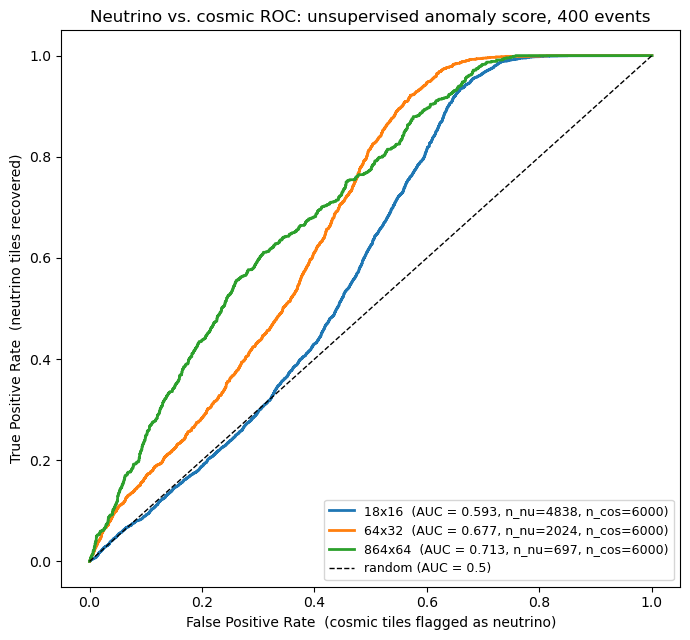

In [1]:
# Neutrino vs. cosmic: a single ROC with one curve per grid slice.
# signal    = tile with >= 1 truth Geant4 neutrino track (>= MIN_HITS plane-2 hits)
# background = pure-cosmic tile: non-empty (lit > 0) but with 0 truth tracks
# Empty tiles are excluded on BOTH sides, so this measures neutrino-vs-cosmic power (not content-vs-empty).
# Same searchsorted event->edep truth mapping as above; scores signal + a per-event cosmic sample.
# Run in the `base` env; ~3 minutes.
import os, numpy as np, h5py
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import roc_curve, roc_auc_score
from mod_data_loader import WireImages
from training import anomaly_score

RAW  = "../../data/ubopendata/bnb_WithWire_00.h5"
PROC = "../../data/ubopendata/processed_npy/bnb_WithWire_00_plane2_images.h5"
MIN_HITS, N_EVENTS, BG_CAP = 5, 400, 15
SIZES = [("18x16", 18, 16, 1024), ("64x32", 64, 32, 512), ("864x64", 864, 64, 16)]
rng = np.random.default_rng(0)

def find_model(base):
    return next(base + e for e in (".h5", ".keras") if os.path.exists(base + e))

data = WireImages(PROC)
f = h5py.File(RAW, "r")
hit_off = np.concatenate([[0], np.cumsum(f["hit_table/event_id.seq_cnt"][:, 1])])
edep_sc = f["edep_table/event_id.seq_cnt"][:]
edep_evid = edep_sc[:, 0]
edep_start = np.concatenate([[0], np.cumsum(edep_sc[:, 1])])

def event_plane2_g4(e):
    hlo, hhi = int(hit_off[e]), int(hit_off[e + 1])
    p2 = f["hit_table/local_plane"][hlo:hhi, 0] == 2
    if not p2.any():
        return None
    hid = f["hit_table/hit_id"][hlo:hhi, 0][p2]
    lw  = f["hit_table/local_wire"][hlo:hhi, 0][p2]
    lt  = f["hit_table/local_time"][hlo:hhi, 0][p2]
    i = np.searchsorted(edep_evid, e)                        # event -> edep rows (may be absent)
    dom = {}
    if i < len(edep_evid) and edep_evid[i] == e:
        elo, ehi = int(edep_start[i]), int(edep_start[i] + edep_sc[i, 1])
        eh = f["edep_table/hit_id"][elo:ehi, 0]
        eg = f["edep_table/g4_id"][elo:ehi, 0]
        ef = f["edep_table/energy_fraction"][elo:ehi, 0]
        for j in np.argsort(-ef):
            k = int(eh[j])
            if k not in dom:
                dom[k] = int(eg[j])
    return lw, lt, np.array([dom.get(int(h), -1) for h in hid])

plt.figure(figsize=(7, 6.5))
for label, sw, st, pb in SIZES:
    model = keras.models.load_model(find_model("../../savedModel/teacher_" + label), compile=False)
    h_split = 640 // st
    Sc, Y = [], []
    for e in range(N_EVENTS):
        segs = data.segments(e, sw, st)
        lit = (segs > 0).reshape(len(segs), -1).sum(1)
        nt = np.zeros(len(segs), dtype=int)
        g = event_plane2_g4(e)
        if g is not None:
            lw, lt, g4 = g
            tile = (lw // sw).astype(int) * h_split + (lt // 10 // st).astype(int)
            for t in np.unique(tile):
                gg = g4[tile == t]; gg = gg[gg >= 0]
                if gg.size:
                    _, c = np.unique(gg, return_counts=True)
                    nt[t] = int((c >= MIN_HITS).sum())
        sig_idx = np.where(nt >= 1)[0]                        # neutrino tiles (score all)
        bg_idx = np.where((nt == 0) & (lit > 0))[0]           # pure-cosmic tiles (sample)
        if len(bg_idx) > BG_CAP:
            bg_idx = rng.choice(bg_idx, BG_CAP, replace=False)
        sel = np.concatenate([sig_idx, bg_idx]).astype(int)
        if len(sel):
            Sc.append(anomaly_score(model, segs[sel], batch_size=pb))
            Y.append(np.concatenate([np.ones(len(sig_idx), int), np.zeros(len(bg_idx), int)]))
    Sc = np.concatenate(Sc); Y = np.concatenate(Y)
    auc = roc_auc_score(Y, Sc); fpr, tpr, _ = roc_curve(Y, Sc)
    plt.plot(fpr, tpr, lw=2, label="%s  (AUC = %.3f, n_nu=%d, n_cos=%d)"
             % (label, auc, int(Y.sum()), int((Y == 0).sum())))
f.close()

plt.plot([0, 1], [0, 1], "k--", lw=1, label="random (AUC = 0.5)")
plt.xlabel("False Positive Rate  (cosmic tiles flagged as neutrino)")
plt.ylabel("True Positive Rate  (neutrino tiles recovered)")
plt.title("Neutrino vs. cosmic ROC: unsupervised anomaly score, %d events" % N_EVENTS)
plt.legend(loc="lower right", fontsize=9); plt.tight_layout(); plt.show()